# **MBG Tweet Classification — IndoBERTweet + Stratified 10-Fold + Soft Voting Ensemble**

| Item | Detail |
|---|---|
| **Model** | `indolem/indobertweet-base-uncased` |
| **Task** | 8-class multiclass text classification |
| **Imbalance** | Weighted Cross-Entropy Loss (sklearn `balanced`) |
| **Validation** | Stratified 10-Fold CV (90 : 10 per fold) |
| **Metric** | Balanced Accuracy |
| **Inference** | Soft-Voting Ensemble over Top-Folds (delta ≤ 0.05 from max) |
| **Emoji Policy** | Raw emojis preserved — native to IndoBERTweet vocab |
| **OOP** | None (Trainer subclass only for `compute_loss` override) |
| **SMOTE** | None |

---
# **Libraries & Framework Setup**

In [22]:
# ── Uncomment to install on Kaggle / Colab (first run only) ──────────────────
# !pip install -q transformers datasets accelerate sentencepiece scikit-learn
#              pandas numpy matplotlib seaborn openpyxl

import os
import re
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device detection ──────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ── Global paths & constants ──────────────────────────────────────────────────
TRAIN_PATH        = '/kaggle/input/datasets/muhammadabilhasan/case1-dataset/case_1_labeled_data.csv'
PREDICT_PATH      = '/kaggle/input/datasets/muhammadabilhasan/case1-dataset/case_1_text_to_predict.csv'
OUTPUT_PATH       = './Pisau Laut Jawa.xlsx'
MODEL_NAME        = 'indolem/indobertweet-base-uncased'
CHECKPOINT_ROOT   = Path('./model_fold')
CHECKPOINT_ROOT.mkdir(exist_ok=True)

MAX_LEN           = 128
N_FOLDS           = 10
TOP_FOLD_DELTA    = 0.02      # folds within this margin of max BAC are selected

# ── Label space (fixed order → stable label↔id mapping) ─────────────────────
LABEL_CLASSES = [
    'Anggaran',
    'Kualitas Pangan',
    'Distribusi',
    'Ekonomi',
    'Tata Kelola',
    'Sasaran Penerima',
    'Politik',
    'Lainnya',
]
NUM_CLASSES = len(LABEL_CLASSES)
LABEL2ID    = {lbl: i for i, lbl in enumerate(LABEL_CLASSES)}
ID2LABEL    = {i: lbl for lbl, i in LABEL2ID.items()}

print(f"\nLabel mapping  : {LABEL2ID}")
print(f"Num classes    : {NUM_CLASSES}")

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU name        : Tesla T4
VRAM total      : 15.64 GB

Label mapping  : {'Anggaran': 0, 'Kualitas Pangan': 1, 'Distribusi': 2, 'Ekonomi': 3, 'Tata Kelola': 4, 'Sasaran Penerima': 5, 'Politik': 6, 'Lainnya': 7}
Num classes    : 8


---
# **EDA**

## **EDA: Missing Values & Duplicate Check**

In [2]:
# ── Load training data (CSV or XLSX) ─────────────────────────────────────────
def load_flexible(path: str) -> pd.DataFrame:
    """Load CSV or XLSX transparently."""
    p = str(path).lower()
    if p.endswith('.xlsx') or p.endswith('.xls'):
        return pd.read_excel(path)
    return pd.read_csv(path)

df_raw = load_flexible(TRAIN_PATH)

print("=" * 60)
print(" RAW DATA OVERVIEW")
print("=" * 60)
print(f"Shape          : {df_raw.shape}")
print(f"Columns        : {df_raw.columns.tolist()}")
print(f"\nDtypes:")
print(df_raw.dtypes)
print()

# ── Missing values ────────────────────────────────────────────────────────────
print("=" * 60)
print(" MISSING VALUES")
print("=" * 60)
missing = df_raw.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("✓ No missing values found.")
else:
    df_raw = df_raw.dropna(subset=['full_text', 'label']).reset_index(drop=True)
    print(f"Rows after dropping NaNs: {len(df_raw)}")

print()

# ── Exact duplicate analysis ─────────────────────────────────────────────────
print("=" * 60)
print(" EXACT DUPLICATE ANALYSIS (full_text)")
print("=" * 60)
shape_before = df_raw.shape
n_dupes      = df_raw.duplicated(subset=['full_text'], keep=False).sum()

print(f"Shape BEFORE dedup   : {shape_before}")
print(f"Duplicate rows found : {n_dupes}")

if n_dupes > 0:
    print("\nSample duplicate entries (up to 10 rows):")
    dupe_mask = df_raw.duplicated(subset=['full_text'], keep=False)
    display(
        df_raw[dupe_mask]
        .sort_values('full_text')
        .head(10)[['full_text', 'label']]
    )

# Drop duplicates — keep first occurrence, reset index
df = (
    df_raw
    .drop_duplicates(subset=['full_text'], keep='first')
    .reset_index(drop=True)
)
shape_after = df.shape

print(f"\nShape AFTER  dedup   : {shape_after}")
print(f"Rows removed         : {shape_before[0] - shape_after[0]}")

# Encode labels — done once, stays in sync through all cells
df['label_id'] = df['label'].map(LABEL2ID)

print("\nFinal DataFrame (head 8):")
display(df.head(8))

 RAW DATA OVERVIEW
Shape          : (5000, 2)
Columns        : ['full_text', 'label']

Dtypes:
full_text    object
label        object
dtype: object

 MISSING VALUES
full_text    0
label        0
dtype: int64
✓ No missing values found.

 EXACT DUPLICATE ANALYSIS (full_text)
Shape BEFORE dedup   : (5000, 2)
Duplicate rows found : 2

Sample duplicate entries (up to 10 rows):


,full_text,label
834,@BosPurwa MBG = Makan Beracun Gratis,Kualitas Pangan
2214,@BosPurwa MBG = Makan Beracun Gratis,Kualitas Pangan



Shape AFTER  dedup   : (4999, 2)
Rows removed         : 1

Final DataFrame (head 8):


,full_text,label,label_id
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima,5
1,MBG bentuk penggarongan duit negara secara TSM...,Politik,6
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima,5
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima,5
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik,6
5,@anakayahumi09 @irularr_ @ARSIPAJA Harus tetap...,Kualitas Pangan,1
6,🍱 Polsek Teluk Nibung monitoring Makan Bergizi...,Distribusi,2
7,eiw efisiensi tai nyusahin huwekk kemana duitn...,Anggaran,0


---
## **EDA: Visualizations**

 CLASS DISTRIBUTION
Class                   Count       %
----------------------------------------
  Anggaran                727  ( 14.5%)  ████████████████████
  Kualitas Pangan        1246  ( 24.9%)  ███████████████████████████████████
  Distribusi              433  (  8.7%)  ████████████
  Ekonomi                 145  (  2.9%)  ████
  Tata Kelola             511  ( 10.2%)  ██████████████
  Sasaran Penerima        507  ( 10.1%)  ██████████████
  Politik                 792  ( 15.8%)  ██████████████████████
  Lainnya                 638  ( 12.8%)  █████████████████

Imbalance ratio (max / min) : 8.6×


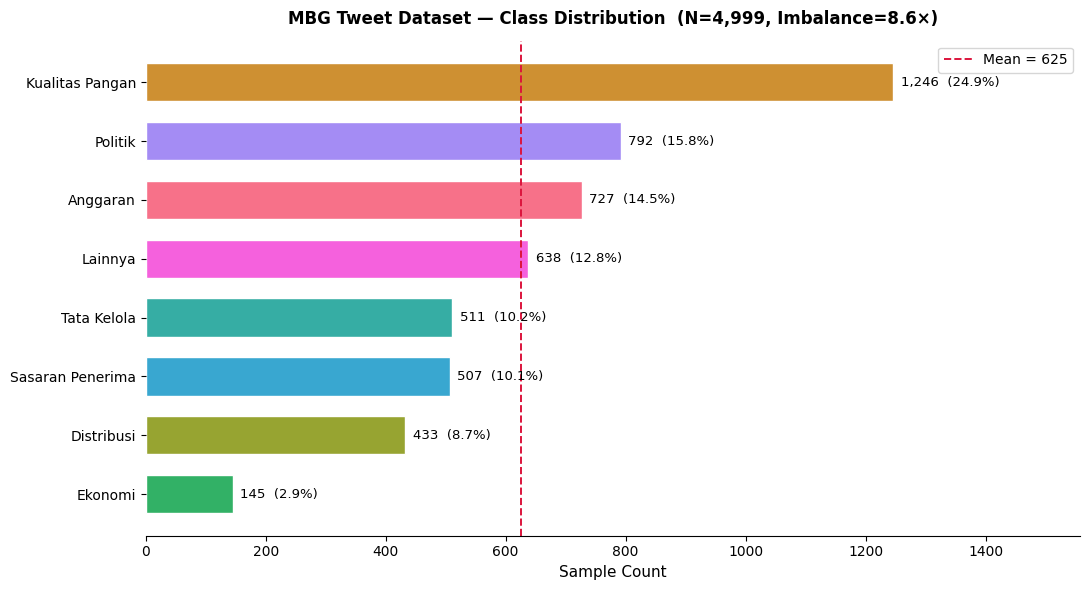

Saved → eda_class_distribution.png


In [3]:
# ── 3-A  Class distribution — horizontal bar chart ───────────────────────────
label_counts = df['label'].value_counts().reindex(LABEL_CLASSES)
label_pct    = label_counts / label_counts.sum() * 100
imbalance_ratio = label_counts.max() / label_counts.min()

print("=" * 60)
print(" CLASS DISTRIBUTION")
print("=" * 60)
print(f"{'Class':<22} {'Count':>6}  {'%':>6}")
print("-" * 40)
for lbl in LABEL_CLASSES:
    bar = '█' * int(label_counts[lbl] / label_counts.max() * 35)
    print(f"  {lbl:<20} {label_counts[lbl]:>6}  ({label_pct[lbl]:5.1f}%)  {bar}")
print(f"\nImbalance ratio (max / min) : {imbalance_ratio:.1f}×")

palette = sns.color_palette('husl', n_colors=NUM_CLASSES)
sort_idx = label_counts.sort_values().index   # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    sort_idx,
    label_counts[sort_idx],
    color=[palette[LABEL_CLASSES.index(l)] for l in sort_idx],
    edgecolor='white',
    height=0.65,
)
for bar, lbl in zip(bars, sort_idx):
    cnt = label_counts[lbl]
    ax.text(
        bar.get_width() + label_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{cnt:,}  ({cnt/label_counts.sum()*100:.1f}%)',
        va='center', fontsize=9.5,
    )
ax.axvline(
    label_counts.mean(), color='crimson', linestyle='--',
    linewidth=1.4, label=f'Mean = {label_counts.mean():.0f}'
)
ax.set_xlabel('Sample Count', fontsize=11)
ax.set_title(
    f'MBG Tweet Dataset — Class Distribution  (N={len(df):,}, Imbalance={imbalance_ratio:.1f}×)',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xlim(0, label_counts.max() * 1.25)
ax.legend(fontsize=10)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → eda_class_distribution.png")

 WORD COUNT STATISTICS
count    4999.0
mean       20.8
std        12.6
min         1.0
25%        11.0
50%        17.0
75%        31.0
max        68.0
Name: word_count, dtype: float64

Tweets ≤ 128 words (proxy for token fit) : 100.0%
Tweets > 128 words (will be truncated)    : 0.0%


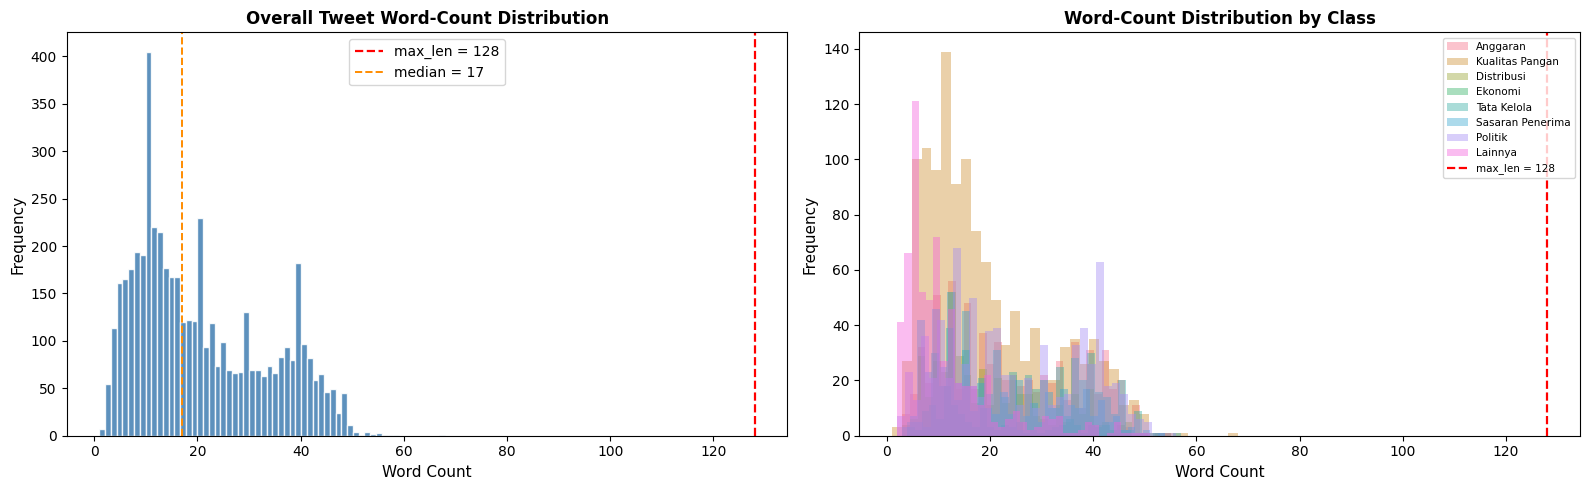

Saved → eda_word_length.png


,full_text,label,label_id,word_count
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima,5,20
1,MBG bentuk penggarongan duit negara secara TSM...,Politik,6,10
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima,5,32
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima,5,12
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik,6,15
5,@anakayahumi09 @irularr_ @ARSIPAJA Harus tetap...,Kualitas Pangan,1,14
6,🍱 Polsek Teluk Nibung monitoring Makan Bergizi...,Distribusi,2,33
7,eiw efisiensi tai nyusahin huwekk kemana duitn...,Anggaran,0,12
8,@kiharani Kesejahteraan petani naik karena MBG...,Ekonomi,3,11
9,@detikcom Ini lagi presiden main sandiwara.......,Sasaran Penerima,5,33


In [4]:
# ── 3-B  Tweet word-length distribution ──────────────────────────────────────
df['word_count'] = df['full_text'].astype(str).apply(lambda x: len(x.split()))

print("=" * 60)
print(" WORD COUNT STATISTICS")
print("=" * 60)
print(df['word_count'].describe().round(1))
pct_within = (df['word_count'] <= MAX_LEN).mean() * 100
print(f"\nTweets ≤ {MAX_LEN} words (proxy for token fit) : {pct_within:.1f}%")
print(f"Tweets > {MAX_LEN} words (will be truncated)    : {100 - pct_within:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Overall histogram
axes[0].hist(
    df['word_count'], bins=60,
    color='steelblue', edgecolor='white', alpha=0.88
)
axes[0].axvline(
    MAX_LEN, color='red', linestyle='--', linewidth=1.6,
    label=f'max_len = {MAX_LEN}'
)
axes[0].axvline(
    df['word_count'].median(), color='darkorange', linestyle='--',
    linewidth=1.4, label=f'median = {df["word_count"].median():.0f}'
)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Overall Tweet Word-Count Distribution', fontweight='bold')
axes[0].legend()

# — Per-class overlapping histogram
for i, lbl in enumerate(LABEL_CLASSES):
    axes[1].hist(
        df[df['label'] == lbl]['word_count'],
        bins=35, alpha=0.42, label=lbl, color=palette[i]
    )
axes[1].axvline(
    MAX_LEN, color='red', linestyle='--',
    linewidth=1.6, label=f'max_len = {MAX_LEN}'
)
axes[1].set_xlabel('Word Count', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Word-Count Distribution by Class', fontweight='bold')
axes[1].legend(fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.savefig('eda_word_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → eda_word_length.png")

# Inspect DataFrame
df[['full_text', 'label', 'label_id', 'word_count']].head(10)

---
# **Procedural Cleaning & Slang Mapping**

In [5]:
# ── 4-A  Slang / abbreviation dictionary ─────────────────────────────────────
#
# Policy: do NOT demojize. Raw emojis are tokenized natively by IndoBERTweet.
# Slang: word-level replacement only, applied AFTER lowercasing.

SLANG_URL = (
    'https://raw.githubusercontent.com/adeariniputri/text-preprocesing/master/slang.csv'
)
SLANG_DICT = {}

kamus_df = pd.read_csv(SLANG_URL, header=None, names=['slang', 'formal'])
for index, row in kamus_df.iterrows():
    if row[0] not in SLANG_DICT:
        SLANG_DICT[row[0]] = row[1] 
print(f"Loaded {len(kamus_df)} slang entries from remote CSV 2.")
print(f"Merged slang dictionary size: {len(SLANG_DICT)} entries.")

SLANG_MAP = {
    # ── Financial abbreviations (competition-critical) ────────────────────
    'jt'         : 'juta',
    'juta'       : 'juta',
    'rb'         : 'ribu',
    'rbu'        : 'ribu',
    'ribu'       : 'ribu',
    't'          : 'triliun',
    'T'          : 'triliun',
    'triliun'    : 'triliun',
    'M'          : 'miliar',
    'miliar'     : 'miliar',

    # ── MBG domain ───────────────────────────────────────────────────────
    'mbg'        : 'makan bergizi gratis',
    'apbn'       : 'anggaran pendapatan belanja negara',
    'pemda'      : 'pemerintah daerah',
    'pemkot'     : 'pemerintah kota',
    'pemkab'     : 'pemerintah kabupaten',
    'tsm'        : 'terstruktur sistematis masif',

    # ── Pronouns ─────────────────────────────────────────────────────────
    'gw'         : 'saya',   'gue'     : 'saya',   'aku'    : 'saya',
    'lo'         : 'kamu',   'lu'      : 'kamu',

    # ── Common abbreviations ──────────────────────────────────────────────
    'yg'         : 'yang',   'dgn'     : 'dengan',  'utk'   : 'untuk',
    'krn'        : 'karena', 'kpd'     : 'kepada',  'tsb'   : 'tersebut',
    'sdh'        : 'sudah',  'udah'    : 'sudah',   'udh'   : 'sudah',
    'blm'        : 'belum',  'jd'      : 'jadi',    'pd'    : 'pada',
    'dr'         : 'dari',   'sbg'     : 'sebagai', 'org'   : 'orang',
    'bgt'        : 'banget', 'nih'     : 'ini',     'tuh'   : 'itu',
    'kyk'        : 'seperti','doang'   : 'saja',    'mah'   : 'memang',
    'kalo'       : 'kalau',  'gimana'  : 'bagaimana',
    'emang'      : 'memang', 'beneran' : 'sungguhan',
    'pake'       : 'pakai',  'abis'    : 'habis',
    'anak2'      : 'anak-anak',

    # ── Negations (preserve for sentiment) ───────────────────────────────
    'nggak'      : 'tidak',  'ngga'    : 'tidak',   'ga'    : 'tidak',
    'enggak'     : 'tidak',  'gak'     : 'tidak',   'tdk'   : 'tidak',

    # ── Laughter / filler tokens ─────────────────────────────────────────
    'wkwk'       : 'haha',   'wkwkwk'  : 'haha',   'kwkwk' : 'haha',
    'hehe'       : 'senyum', 'hihi'    : 'senyum',
}

print(f"Slang dictionary entries : {len(SLANG_MAP)}")
SLANG_MAP.update(SLANG_DICT)
pd.DataFrame(list(SLANG_MAP.items()), columns=['slang', 'formal']).head(20)

Loaded 1544 slang entries from remote CSV 2.
Merged slang dictionary size: 1481 entries.
Slang dictionary entries : 60


,slang,formal
0,jt,juta
1,juta,juta
2,rb,ribu
3,rbu,ribu
4,ribu,ribu
5,t,triliun
6,T,triliun
7,triliun,triliun
8,M,miliar
9,miliar,miliar


In [6]:
# ── 4-B  Compile regex patterns ───────────────────────────────────────────────
RE_URL     = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
RE_MENTION = re.compile(r'@\w+')           # strip @handles
RE_HASHTAG = re.compile(r'#(\w+)')         # strip '#', keep word
RE_REPEAT  = re.compile(r'(.)\1{2,}')      # bangeeeet → bangeet (≤2 repeats)
RE_SPACES  = re.compile(r'\s+')

# ── Unicode emoji pattern (preserve these through entire pipeline) ────────────
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)


def apply_slang_map(text: str) -> str:
    """Word-level slang/abbreviation substitution."""
    return ' '.join(SLANG_MAP.get(w, w) for w in text.split())


def clean_tweet(text: str) -> str:
    """
    Standalone text cleaning function for IndoBERTweet.

    Steps (ORDER MATTERS):
      1. Guard: handle non-string input.
      2. Extract raw emojis — re-appended after text cleaning so they
         survive lowercasing and character stripping intact.
      3. Lowercase the non-emoji portion.
      4. Remove URLs.
      5. Remove Twitter @handles.
      6. Strip '#' from hashtags, keep the word.
      7. Collapse 3+ repeated characters to 2.
      8. Apply slang / abbreviation dictionary.
      9. Remove remaining non-alphanumeric chars (except whitespace & punctuation).
     10. Collapse whitespace.
     11. Re-attach raw emojis at the end.
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # Step 2 — extract & protect emojis
    emojis_found = EMOJI_PATTERN.findall(text)
    text = EMOJI_PATTERN.sub(' ', text)

    # Step 3
    text = text.lower()

    # Steps 4-6
    text = RE_URL.sub(' ', text)
    text = RE_MENTION.sub(' ', text)
    text = RE_HASHTAG.sub(r'\1', text)

    # Step 7
    text = RE_REPEAT.sub(r'\1\1', text)

    # Step 8
    text = apply_slang_map(text)

    # Step 9 — keep alphanumeric, whitespace, and sentence punctuation
    text = re.sub(r'[^\w\s.,!?;:\-]', ' ', text)

    # Step 10
    text = RE_SPACES.sub(' ', text).strip()

    # Step 11
    if emojis_found:
        text = text + ' ' + ' '.join(emojis_found)

    return text


# ── Sanity check ──────────────────────────────────────────────────────────────
_sanity = [
    "@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja belatung 😡😡 https://t.co/abc",
    "MBG habiskan 71 jt APBN utk anak2 yg ga dapat manfaatnya 💸",
    "Distribusi makan bergizi blm merata, 1.2 t anggaran entah kemana #MBG2025",
    "Makanannya enak bangeeeet 🍱 tapi kyk mie instan doang ga bergizi sama sekali",
    "wkwkwk TSM banget kebijakan MBG nggak jelas arah tujuannya 🤦",
]
print("=" * 65)
print(" CLEAN_TWEET SANITY CHECK")
print("=" * 65)
for t in _sanity:
    print(f"  IN : {t}")
    print(f"  OUT: {clean_tweet(t)}")
    print()

 CLEAN_TWEET SANITY CHECK
  IN : @ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja belatung 😡😡 https://t.co/abc
  OUT: pret. di sekolah aku dapat makan bergizi gratis tetap saja belatung 😡😡

  IN : MBG habiskan 71 jt APBN utk anak2 yg ga dapat manfaatnya 💸
  OUT: makan bergizi gratis habiskan 71 juta anggaran pendapatan belanja negara untuk anak-anak yang tidak dapat manfaatnya 💸

  IN : Distribusi makan bergizi blm merata, 1.2 t anggaran entah kemana #MBG2025
  OUT: distribusi makan bergizi belum merata, 1.2 triliun anggaran entah kemana mbg2025

  IN : Makanannya enak bangeeeet 🍱 tapi kyk mie instan doang ga bergizi sama sekali
  OUT: makanannya enak bangeet tapi seperti mie instan saja tidak bergizi sama sekali 🍱

  IN : wkwkwk TSM banget kebijakan MBG nggak jelas arah tujuannya 🤦
  OUT: haha terstruktur sistematis masif sekali kebijakan makan bergizi gratis tidak jelas arah tujuannya 🤦



In [7]:
# ── 4-C  Apply cleaning to the training DataFrame ─────────────────────────────
df['text_clean'] = df['full_text'].apply(clean_tweet)

# Drop rows that became empty strings post-cleaning
n_pre  = len(df)
df     = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
n_post = len(df)
print(f"Rows before empty-text drop : {n_pre}")
print(f"Rows after  empty-text drop : {n_post}  ({n_pre - n_post} removed)")

# Update word count on clean text
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

print("\nDataFrame after cleaning (head 10):")
display(df[['full_text', 'text_clean', 'label', 'label_id', 'word_count', 'clean_word_count']].head(10))

Rows before empty-text drop : 4999
Rows after  empty-text drop : 4999  (0 removed)

DataFrame after cleaning (head 10):


,full_text,text_clean,label,label_id,word_count,clean_word_count
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,pret. di sekolah aku dapat makan bergizi grati...,Sasaran Penerima,5,20,22
1,MBG bentuk penggarongan duit negara secara TSM...,makan bergizi gratis bentuk penggarongan uang ...,Politik,6,10,15
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,pasal 34 ayat 1 undang-undang dasar negara rep...,Sasaran Penerima,5,32,29
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,makan bergizi gratis bikin masyarakat ngerasa ...,Sasaran Penerima,5,12,11
4,"@OniSuryaman Presiden ngotot, paling sebel kal...","presiden ngotot, paling kesal kalau makan berg...",Politik,6,15,16
5,@anakayahumi09 @irularr_ @ARSIPAJA Harus tetap...,"harus tetap dimakan karena namanya saja mbg, m...",Kualitas Pangan,1,14,10
6,🍱 Polsek Teluk Nibung monitoring Makan Bergizi...,polsek teluk nibung monitoring makan bergizi g...,Distribusi,2,33,32
7,eiw efisiensi tai nyusahin huwekk kemana duitn...,eiw efisiensi tahi nyusahin huwekk kemana duit...,Anggaran,0,12,14
8,@kiharani Kesejahteraan petani naik karena MBG...,kesejahteraan petani naik karena makan bergizi...,Ekonomi,3,11,12
9,@detikcom Ini lagi presiden main sandiwara.......,ini lagi presiden main sandiwara.. sudah jelas...,Sasaran Penerima,5,33,36


---
# **Tokenization & Class Weights Calculation**

In [8]:
# ── 5-A  Load IndoBERTweet tokenizer ─────────────────────────────────────────
print(f"Loading tokenizer: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")
print(f"  Vocab size       : {tokenizer.vocab_size:,}")
print(f"  Model max length : {tokenizer.model_max_length}")
print(f"  We will use      : {MAX_LEN} tokens")

# ── Verify tokenization on a real sample ─────────────────────────────────────
_sample_text = df['text_clean'].iloc[0]
_enc = tokenizer(
    _sample_text,
    max_length=MAX_LEN,
    truncation=True,
    padding='max_length',
    return_tensors='pt',
)
print(f"\nSample text          : {_sample_text[:85]}...")
print(f"input_ids shape      : {_enc['input_ids'].shape}")
print(f"Non-padding tokens   : {_enc['attention_mask'].sum().item()}")

# ── DataCollator: dynamic padding (saves memory vs fixed max_len padding) ─────
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading tokenizer: indolem/indobertweet-base-uncased ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded.
  Vocab size       : 31,923
  Model max length : 1000000000000000019884624838656
  We will use      : 128 tokens

Sample text          : pret. di sekolah aku dapat makan bergizi gratis tetap saja anak-anaknya pada jajan la...
input_ids shape      : torch.Size([1, 128])
Non-padding tokens   : 30


In [9]:
# ── 5-B  Tokenize helper — used inside each fold's HF Dataset ────────────────
def tokenize_batch(examples):
    """
    Tokenize a batch of texts for HF Dataset.map().
    padding=False → DataCollatorWithPadding handles dynamic padding per batch.
    """
    return tokenizer(
        examples['text'],
        max_length = MAX_LEN,
        truncation = True,
        padding    = False,
    )

print("tokenize_batch function defined.")

tokenize_batch function defined.


 BALANCED CLASS WEIGHTS
ID   Class                     n_c    weight
---------------------------------------------
  0   Anggaran                  727     0.8595
  1   Kualitas Pangan          1246     0.5015
  2   Distribusi                433     1.4431
  3   Ekonomi                   145     4.3095
  4   Tata Kelola               511     1.2228
  5   Sasaran Penerima          507     1.2325
  6   Politik                   792     0.7890
  7   Lainnya                   638     0.9794

Min weight : 0.5015  (Kualitas Pangan)
Max weight : 4.3095  (Ekonomi)
Weight range ratio : 8.59×


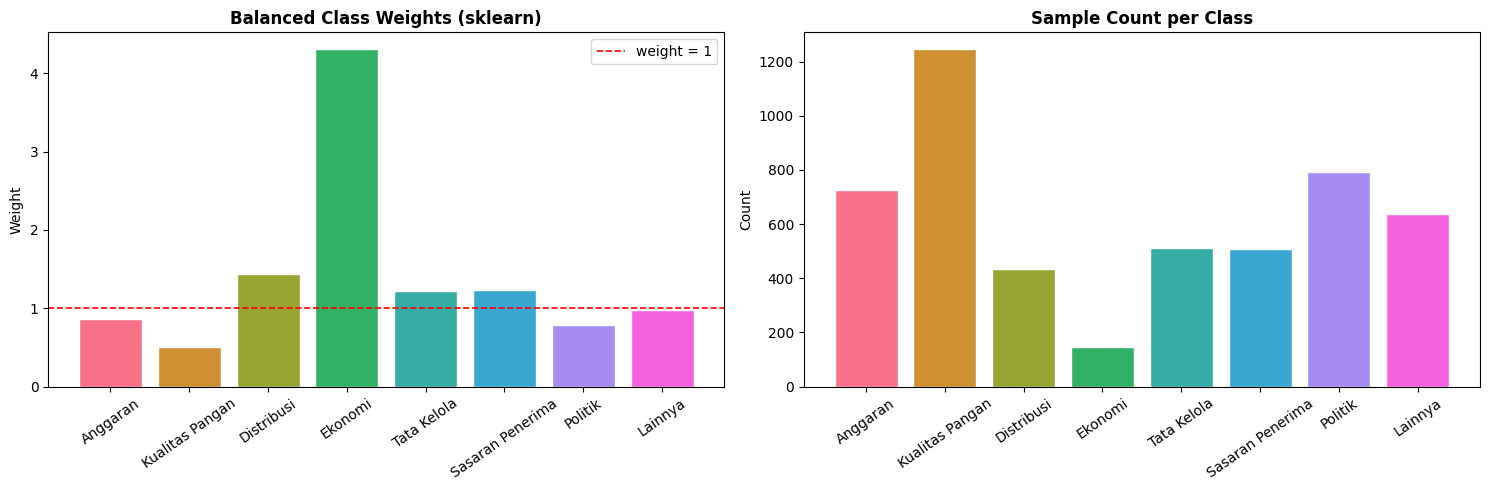

Saved → class_weights.png


In [10]:
# ── 5-C  Class weights via sklearn 'balanced' heuristic ──────────────────────
#
# Formula: w_c = N / (C × n_c)
# This gives higher weight to under-represented classes without any oversampling.

label_ids_arr = df['label_id'].values
unique_classes = np.array(sorted(df['label_id'].unique()))

raw_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = unique_classes,
    y            = label_ids_arr,
)

CLASS_WEIGHTS_TENSOR = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

print("=" * 60)
print(" BALANCED CLASS WEIGHTS")
print("=" * 60)
print(f"{'ID':<4} {'Class':<22} {'n_c':>6}  {'weight':>8}")
print("-" * 45)
for cid in unique_classes:
    cname = ID2LABEL[cid]
    nc    = (label_ids_arr == cid).sum()
    w     = raw_weights[cid]
    print(f"  {cid:<3} {cname:<22} {nc:>6}   {w:>8.4f}")

print(f"\nMin weight : {raw_weights.min():.4f}  ({ID2LABEL[raw_weights.argmin()]})")
print(f"Max weight : {raw_weights.max():.4f}  ({ID2LABEL[raw_weights.argmax()]})")
print(f"Weight range ratio : {raw_weights.max()/raw_weights.min():.2f}×")

# Visualise weights alongside class counts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(LABEL_CLASSES, [raw_weights[LABEL2ID[l]] for l in LABEL_CLASSES],
            color=palette, edgecolor='white')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='weight = 1')
axes[0].set_title('Balanced Class Weights (sklearn)', fontweight='bold')
axes[0].set_ylabel('Weight')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend()

axes[1].bar(LABEL_CLASSES, [label_counts[l] for l in LABEL_CLASSES],
            color=palette, edgecolor='white')
axes[1].set_title('Sample Count per Class', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('class_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → class_weights.png")

---
# **Custom Loss Definition & Custom Trainer**

In [11]:
# ── Custom Trainer: ONLY compute_loss is overridden ──────────────────────────
#
# All other Trainer functionality (evaluation loop, checkpointing,
# early stopping, logging, fp16 scaler) remains standard HF Trainer.
#
# CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR) replaces the default
# unweighted CE loss, forcing the model to pay more attention to
# under-represented classes (Ekonomi: 145 samples → highest weight).

class WeightedCETrainer(Trainer):
    """Hugging Face Trainer with Weighted Cross-Entropy Loss."""

    def __init__(self, class_weights: torch.Tensor, *args, **kwargs):
        tokenizer = kwargs.pop('tokenizer', None)
        super().__init__(*args, **kwargs)
        # Keep weights on the correct device — resolved at first forward pass
        self._class_weights = class_weights.to(self.args.device)
        if tokenizer is not None:
            self.tokenizer = tokenizer

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits

        # Move weights to the same device as logits (handles multi-GPU edge cases)
        weights = self._class_weights.to(logits.device)

        loss_fn = nn.CrossEntropyLoss(weight=weights)
        loss    = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss


# ── Metric function (used by Trainer for eval_balanced_accuracy) ─────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=-1)
    bac            = balanced_accuracy_score(labels, preds)
    return {'balanced_accuracy': round(bac, 6)}


print("WeightedCETrainer and compute_metrics defined.")

# ── Quick sanity: confirm weighted CE runs without error ─────────────────────
_dummy_logits  = torch.randn(8, NUM_CLASSES)
_dummy_targets = torch.randint(0, NUM_CLASSES, (8,))
_test_loss = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.cpu())(
    _dummy_logits, _dummy_targets
)
print(f"Weighted CE sanity check (random batch): loss = {_test_loss.item():.4f}  ✓")

WeightedCETrainer and compute_metrics defined.
Weighted CE sanity check (random batch): loss = 1.6208  ✓


---
# **Stratified 10-Fold Training Loop (Procedural)**

In [12]:
# ── Training hyper-parameters ─────────────────────────────────────────────────
TRAINING_KWARGS = dict(
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 3e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    lr_scheduler_type           = 'cosine',
    fp16                        = (DEVICE.type == 'cuda'),  # Kaggle GPU acceleration
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'balanced_accuracy',
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 1,       # keep only best checkpoint per fold
    dataloader_num_workers      = 2,
    seed                        = SEED,
    report_to                   = 'none',
)

print("=" * 55)
print(" TRAINING CONFIGURATION")
print("=" * 55)
for k, v in TRAINING_KWARGS.items():
    print(f"  {k:<35} : {v}")

 TRAINING CONFIGURATION
  num_train_epochs                    : 5
  per_device_train_batch_size         : 16
  per_device_eval_batch_size          : 32
  learning_rate                       : 3e-05
  weight_decay                        : 0.01
  warmup_ratio                        : 0.1
  lr_scheduler_type                   : cosine
  fp16                                : True
  eval_strategy                       : epoch
  save_strategy                       : epoch
  load_best_model_at_end              : True
  metric_for_best_model               : balanced_accuracy
  greater_is_better                   : True
  logging_steps                       : 50
  save_total_limit                    : 1
  dataloader_num_workers              : 2
  seed                                : 42
  report_to                           : none


Stratified 10-Fold CV initialized.
Total training samples : 4999
~Approx per fold       : train=4499, val=499


══════════════════════════════════════════════════════════════════════
  FOLD  1 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 1 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 1 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

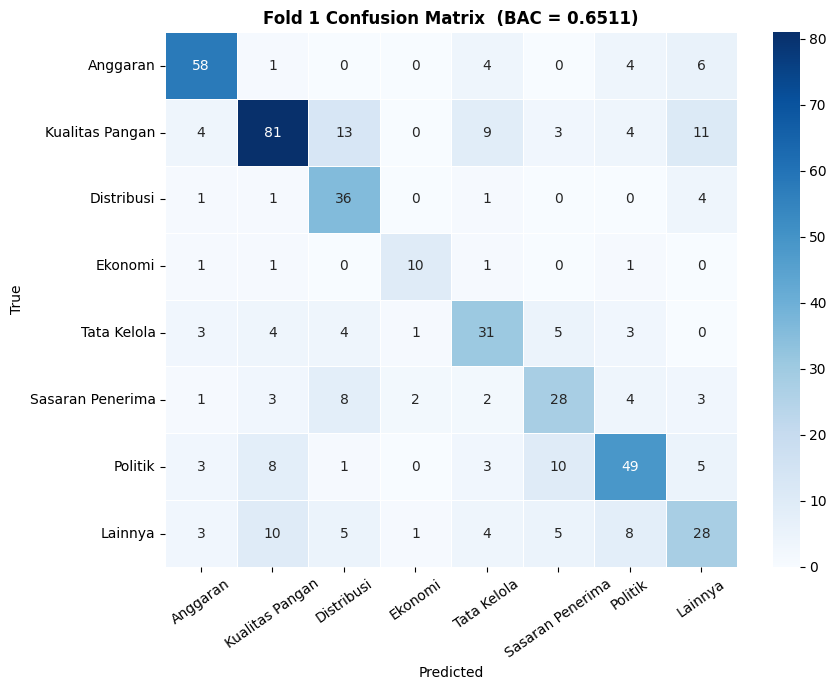


  Fold 1 — val_loss = 1.1257  |  val_BAC = 0.6511
                  precision    recall  f1-score   support

        Anggaran     0.7838    0.7945    0.7891        73
 Kualitas Pangan     0.7431    0.6480    0.6923       125
      Distribusi     0.5373    0.8372    0.6545        43
         Ekonomi     0.7143    0.7143    0.7143        14
     Tata Kelola     0.5636    0.6078    0.5849        51
Sasaran Penerima     0.5490    0.5490    0.5490        51
         Politik     0.6712    0.6203    0.6447        79
         Lainnya     0.4912    0.4375    0.4628        64

        accuracy                         0.6420       500
       macro avg     0.6317    0.6511    0.6365       500
    weighted avg     0.6488    0.6420    0.6413       500


══════════════════════════════════════════════════════════════════════
  FOLD  2 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 2 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 2 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

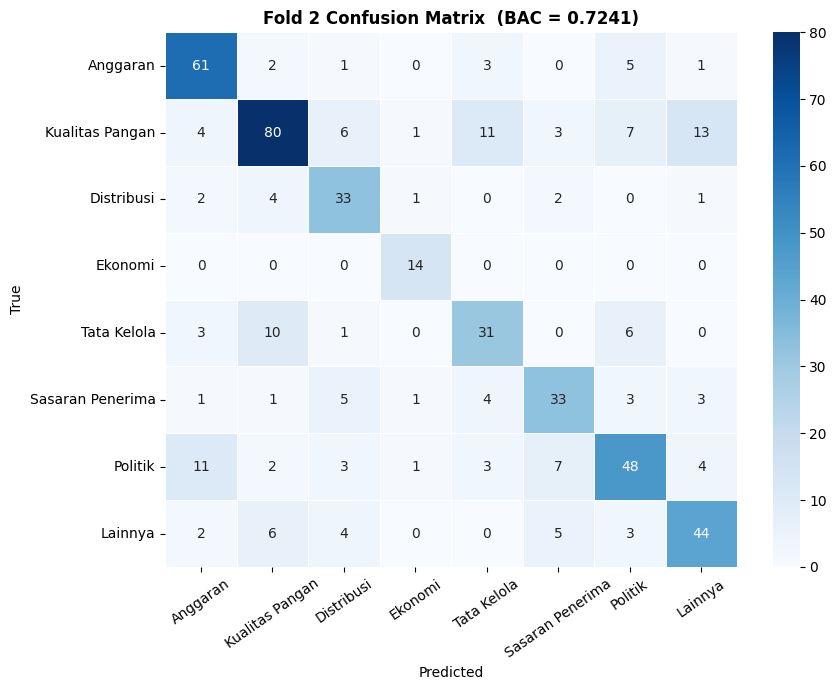


  Fold 2 — val_loss = 0.9280  |  val_BAC = 0.7241
                  precision    recall  f1-score   support

        Anggaran     0.7262    0.8356    0.7771        73
 Kualitas Pangan     0.7619    0.6400    0.6957       125
      Distribusi     0.6226    0.7674    0.6875        43
         Ekonomi     0.7778    1.0000    0.8750        14
     Tata Kelola     0.5962    0.6078    0.6019        51
Sasaran Penerima     0.6600    0.6471    0.6535        51
         Politik     0.6667    0.6076    0.6358        79
         Lainnya     0.6667    0.6875    0.6769        64

        accuracy                         0.6880       500
       macro avg     0.6848    0.7241    0.7004       500
    weighted avg     0.6906    0.6880    0.6861       500


══════════════════════════════════════════════════════════════════════
  FOLD  3 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 3 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 3 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

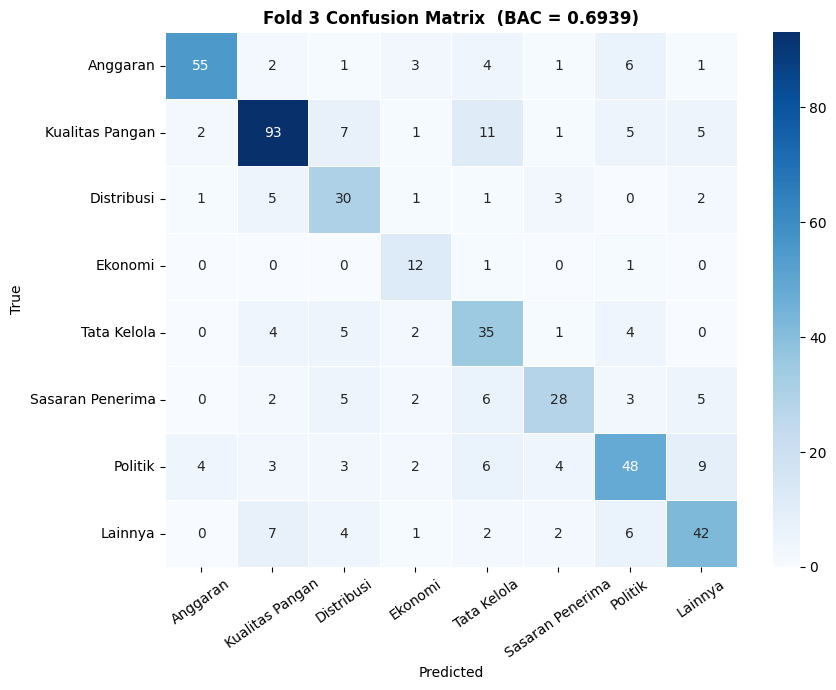


  Fold 3 — val_loss = 0.9343  |  val_BAC = 0.6939
                  precision    recall  f1-score   support

        Anggaran     0.8871    0.7534    0.8148        73
 Kualitas Pangan     0.8017    0.7440    0.7718       125
      Distribusi     0.5455    0.6977    0.6122        43
         Ekonomi     0.5000    0.8571    0.6316        14
     Tata Kelola     0.5303    0.6863    0.5983        51
Sasaran Penerima     0.7000    0.5490    0.6154        51
         Politik     0.6575    0.6076    0.6316        79
         Lainnya     0.6562    0.6562    0.6562        64

        accuracy                         0.6860       500
       macro avg     0.6598    0.6939    0.6665       500
    weighted avg     0.7042    0.6860    0.6898       500


══════════════════════════════════════════════════════════════════════
  FOLD  4 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 4 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 4 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

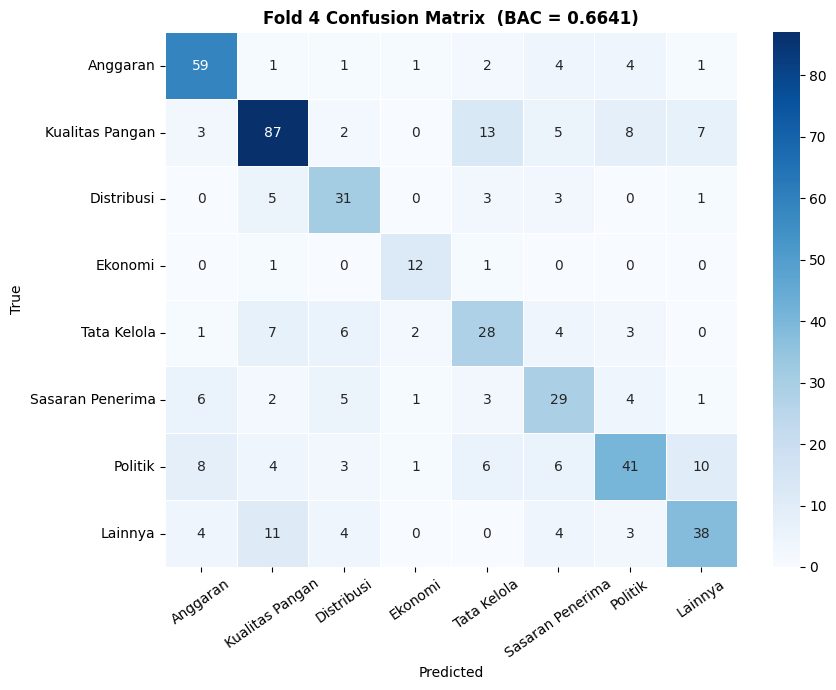


  Fold 4 — val_loss = 1.0595  |  val_BAC = 0.6641
                  precision    recall  f1-score   support

        Anggaran     0.7284    0.8082    0.7662        73
 Kualitas Pangan     0.7373    0.6960    0.7160       125
      Distribusi     0.5962    0.7209    0.6526        43
         Ekonomi     0.7059    0.8571    0.7742        14
     Tata Kelola     0.5000    0.5490    0.5234        51
Sasaran Penerima     0.5273    0.5686    0.5472        51
         Politik     0.6508    0.5190    0.5775        79
         Lainnya     0.6552    0.5938    0.6230        64

        accuracy                         0.6500       500
       macro avg     0.6376    0.6641    0.6475       500
    weighted avg     0.6532    0.6500    0.6489       500


══════════════════════════════════════════════════════════════════════
  FOLD  5 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 5 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 5 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

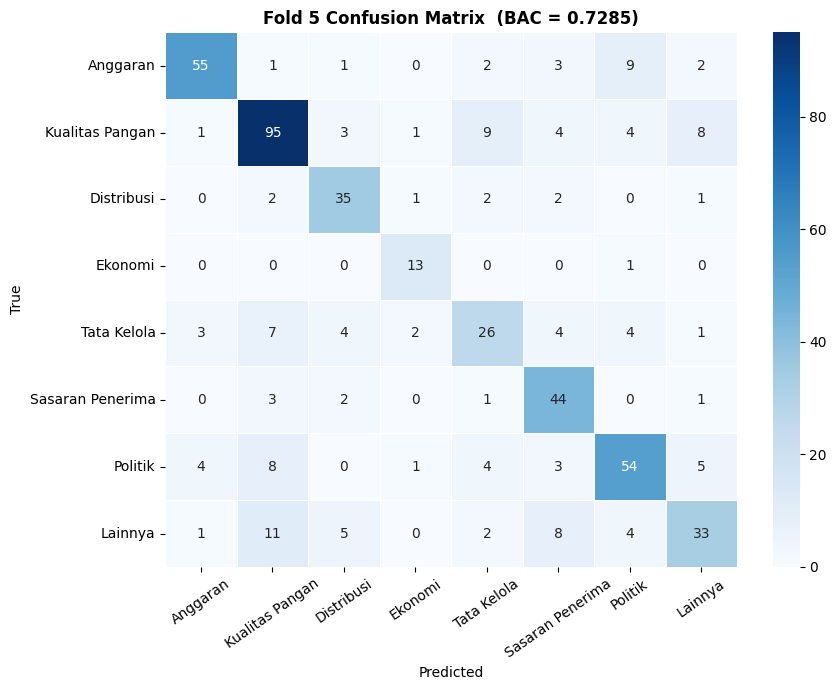


  Fold 5 — val_loss = 0.8758  |  val_BAC = 0.7285
                  precision    recall  f1-score   support

        Anggaran     0.8594    0.7534    0.8029        73
 Kualitas Pangan     0.7480    0.7600    0.7540       125
      Distribusi     0.7000    0.8140    0.7527        43
         Ekonomi     0.7222    0.9286    0.8125        14
     Tata Kelola     0.5652    0.5098    0.5361        51
Sasaran Penerima     0.6471    0.8627    0.7395        51
         Politik     0.7105    0.6835    0.6968        79
         Lainnya     0.6471    0.5156    0.5739        64

        accuracy                         0.7100       500
       macro avg     0.6999    0.7285    0.7085       500
    weighted avg     0.7116    0.7100    0.7069       500


══════════════════════════════════════════════════════════════════════
  FOLD  6 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 6 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 6 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Balanced Accuracy
1,1.655022,1.166916,0.622767
2,0.946192,0.977786,0.694392
3,0.608351,1.025019,0.686091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

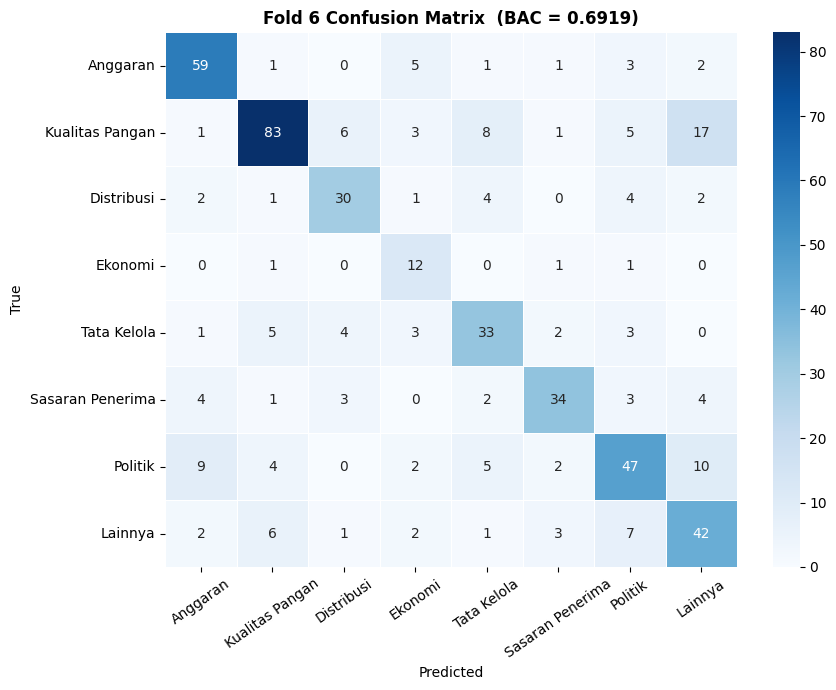


  Fold 6 — val_loss = 0.9774  |  val_BAC = 0.6919
                  precision    recall  f1-score   support

        Anggaran     0.7564    0.8194    0.7867        72
 Kualitas Pangan     0.8137    0.6694    0.7345       124
      Distribusi     0.6818    0.6818    0.6818        44
         Ekonomi     0.4286    0.8000    0.5581        15
     Tata Kelola     0.6111    0.6471    0.6286        51
Sasaran Penerima     0.7727    0.6667    0.7158        51
         Politik     0.6438    0.5949    0.6184        79
         Lainnya     0.5455    0.6562    0.5957        64

        accuracy                         0.6800       500
       macro avg     0.6567    0.6919    0.6650       500
    weighted avg     0.6963    0.6800    0.6833       500


══════════════════════════════════════════════════════════════════════
  FOLD  7 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 7 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 7 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

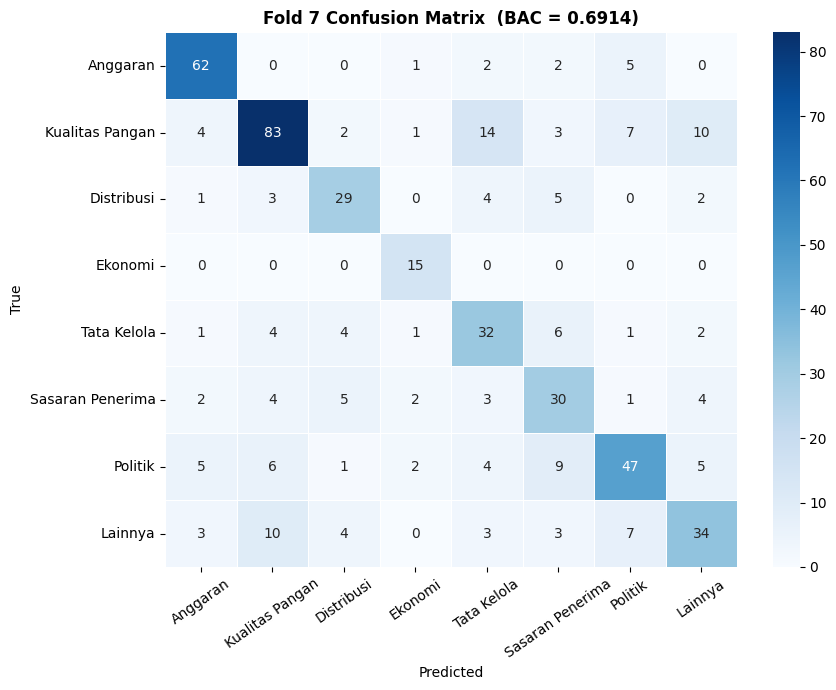


  Fold 7 — val_loss = 0.9714  |  val_BAC = 0.6914
                  precision    recall  f1-score   support

        Anggaran     0.7949    0.8611    0.8267        72
 Kualitas Pangan     0.7545    0.6694    0.7094       124
      Distribusi     0.6444    0.6591    0.6517        44
         Ekonomi     0.6818    1.0000    0.8108        15
     Tata Kelola     0.5161    0.6275    0.5664        51
Sasaran Penerima     0.5172    0.5882    0.5505        51
         Politik     0.6912    0.5949    0.6395        79
         Lainnya     0.5965    0.5312    0.5620        64

        accuracy                         0.6640       500
       macro avg     0.6496    0.6914    0.6646       500
    weighted avg     0.6697    0.6640    0.6635       500


══════════════════════════════════════════════════════════════════════
  FOLD  8 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 8 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 8 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

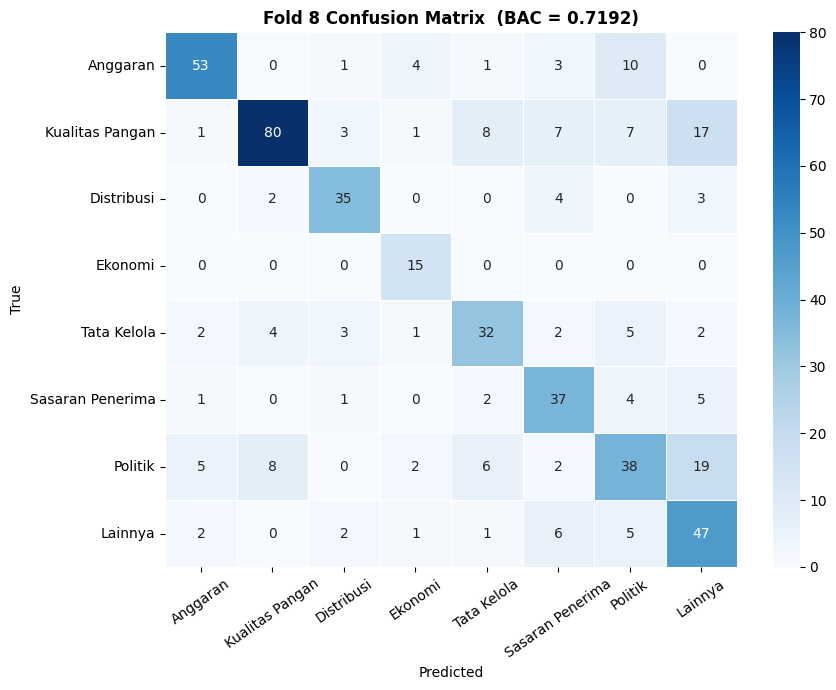


  Fold 8 — val_loss = 0.9004  |  val_BAC = 0.7192
                  precision    recall  f1-score   support

        Anggaran     0.8281    0.7361    0.7794        72
 Kualitas Pangan     0.8511    0.6452    0.7339       124
      Distribusi     0.7778    0.7955    0.7865        44
         Ekonomi     0.6250    1.0000    0.7692        15
     Tata Kelola     0.6400    0.6275    0.6337        51
Sasaran Penerima     0.6066    0.7400    0.6667        50
         Politik     0.5507    0.4750    0.5101        80
         Lainnya     0.5054    0.7344    0.5987        64

        accuracy                         0.6740       500
       macro avg     0.6731    0.7192    0.6848       500
    weighted avg     0.6962    0.6740    0.6761       500


══════════════════════════════════════════════════════════════════════
  FOLD  9 / 10  │  train = 4,499  │  val = 500
══════════════════════════════════════════════════════════════════════


Fold 9 tokenize train:   0%|          | 0/4499 [00:00<?, ? examples/s]

Fold 9 tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

  HF train dataset : 4,499 samples
  HF val   dataset : 500 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

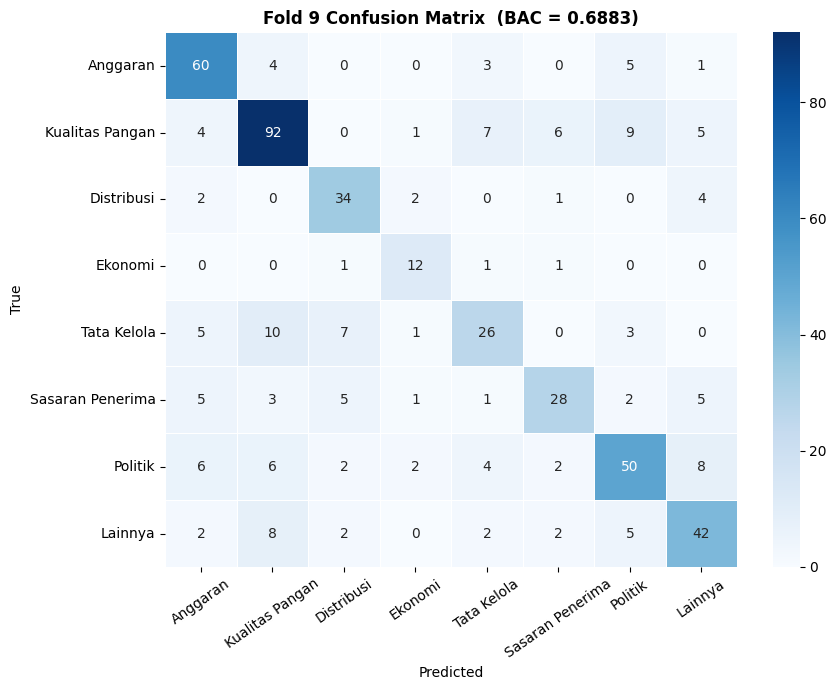


  Fold 9 — val_loss = 0.9540  |  val_BAC = 0.6883
                  precision    recall  f1-score   support

        Anggaran     0.7143    0.8219    0.7643        73
 Kualitas Pangan     0.7480    0.7419    0.7449       124
      Distribusi     0.6667    0.7907    0.7234        43
         Ekonomi     0.6316    0.8000    0.7059        15
     Tata Kelola     0.5909    0.5000    0.5417        52
Sasaran Penerima     0.7000    0.5600    0.6222        50
         Politik     0.6757    0.6250    0.6494        80
         Lainnya     0.6462    0.6667    0.6562        63

        accuracy                         0.6880       500
       macro avg     0.6717    0.6883    0.6760       500
    weighted avg     0.6870    0.6880    0.6849       500


══════════════════════════════════════════════════════════════════════
  FOLD 10 / 10  │  train = 4,500  │  val = 499
══════════════════════════════════════════════════════════════════════


Fold 10 tokenize train:   0%|          | 0/4500 [00:00<?, ? examples/s]

Fold 10 tokenize val:   0%|          | 0/499 [00:00<?, ? examples/s]

  HF train dataset : 4,500 samples
  HF val   dataset : 499 samples


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

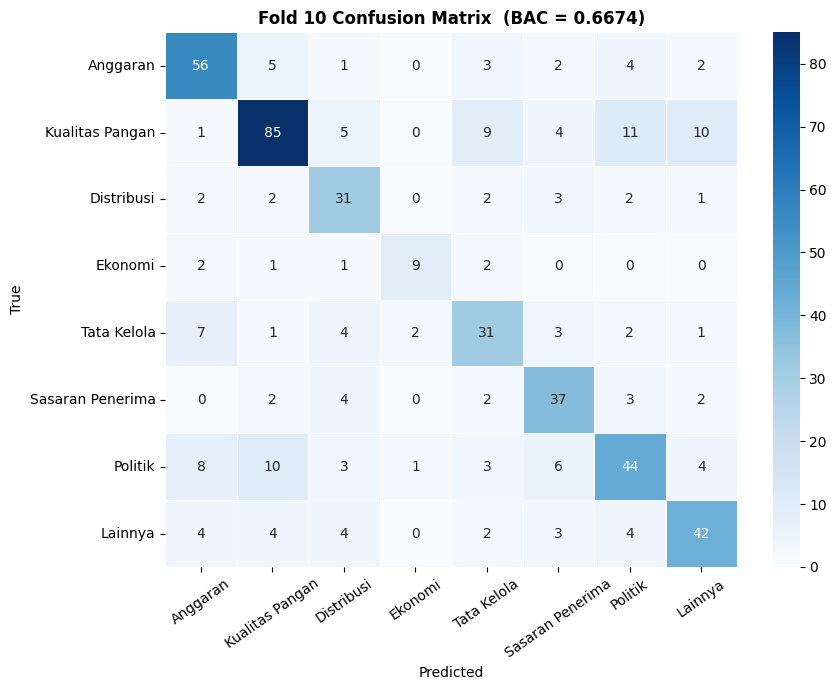


  Fold 10 — val_loss = 1.1119  |  val_BAC = 0.6674
                  precision    recall  f1-score   support

        Anggaran     0.7000    0.7671    0.7320        73
 Kualitas Pangan     0.7727    0.6800    0.7234       125
      Distribusi     0.5849    0.7209    0.6458        43
         Ekonomi     0.7500    0.6000    0.6667        15
     Tata Kelola     0.5741    0.6078    0.5905        51
Sasaran Penerima     0.6379    0.7400    0.6852        50
         Politik     0.6286    0.5570    0.5906        79
         Lainnya     0.6774    0.6667    0.6720        63

        accuracy                         0.6713       499
       macro avg     0.6657    0.6674    0.6633       499
    weighted avg     0.6766    0.6713    0.6713       499


══════════════════════════════════════════════════════════════════════
 ALL FOLDS COMPLETE
══════════════════════════════════════════════════════════════════════
  Fold  1  BAC = 0.6511  ckpt → model_fold/fold_01
  Fold  2  BAC = 0.7241  ckpt → mod

In [13]:
# ── Stratified 10-Fold setup ──────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

texts_arr  = df['text_clean'].values
labels_arr = df['label_id'].values

# Storage: fold_id → {bac_score, checkpoint_dir}
fold_registry  = {}         # {fold_id: {'score': float, 'ckpt_dir': str}}
oof_preds_arr  = np.full(len(labels_arr), -1, dtype=int)

print(f"Stratified {N_FOLDS}-Fold CV initialized.")
print(f"Total training samples : {len(labels_arr)}")
print(f"~Approx per fold       : train={int(len(labels_arr)*0.9)}, val={int(len(labels_arr)*0.1)}")
print()

# ═══════════════════════════════════════════════════════════════════════════════
#  MAIN 10-FOLD TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
for fold, (train_idx, val_idx) in enumerate(
    skf.split(texts_arr, labels_arr), start=1
):
    print()
    print("═" * 70)
    print(f"  FOLD {fold:>2} / {N_FOLDS}  │  train = {len(train_idx):,}  │  val = {len(val_idx):,}")
    print("═" * 70)

    fold_ckpt_dir = str(CHECKPOINT_ROOT / f'fold_{fold:02d}')
    os.makedirs(fold_ckpt_dir, exist_ok=True)

    # ── Build HF Datasets ─────────────────────────────────────────────────
    train_hf = Dataset.from_dict({
        'text'  : texts_arr[train_idx].tolist(),
        'labels': labels_arr[train_idx].tolist(),
    })
    val_hf = Dataset.from_dict({
        'text'  : texts_arr[val_idx].tolist(),
        'labels': labels_arr[val_idx].tolist(),
    })

    # Tokenize in parallel; remove raw 'text' column after tokenization
    train_hf = train_hf.map(
        tokenize_batch, batched=True, remove_columns=['text'],
        desc=f'Fold {fold} tokenize train'
    )
    val_hf = val_hf.map(
        tokenize_batch, batched=True, remove_columns=['text'],
        desc=f'Fold {fold} tokenize val'
    )
    train_hf.set_format('torch')
    val_hf.set_format('torch')

    print(f"  HF train dataset : {len(train_hf):,} samples")
    print(f"  HF val   dataset : {len(val_hf):,} samples")

    # ── Fresh model — new weights each fold ───────────────────────────────
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels              = NUM_CLASSES,
        ignore_mismatched_sizes = True,   # replaces default 2-class head with 8-class
        id2label                = ID2LABEL,
        label2id                = LABEL2ID,
    )

    # ── TrainingArguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir = fold_ckpt_dir,
        **TRAINING_KWARGS,
    )

    # ── Weighted CE Trainer ───────────────────────────────────────────────
    trainer = WeightedCETrainer(
        class_weights  = CLASS_WEIGHTS_TENSOR,
        model          = model,
        args           = training_args,
        train_dataset  = train_hf,
        eval_dataset   = val_hf,
        tokenizer      = tokenizer,
        data_collator  = data_collator,
        compute_metrics= compute_metrics,
        callbacks      = [EarlyStoppingCallback(early_stopping_patience=1)],
    )

    # ── Train ─────────────────────────────────────────────────────────────
    trainer.train()

    # ── Evaluate ─────────────────────────────────────────────────────────
    eval_out  = trainer.evaluate()
    fold_bac  = eval_out['eval_balanced_accuracy']
    fold_loss = eval_out.get('eval_loss', float('nan'))

    # ── OOF predictions ───────────────────────────────────────────────────
    raw_out          = trainer.predict(val_hf)
    fold_pred_ids    = np.argmax(raw_out.predictions, axis=-1)
    oof_preds_arr[val_idx] = fold_pred_ids

    # ── Per-fold confusion matrix ─────────────────────────────────────────
    fold_true = labels_arr[val_idx]
    cm_f      = confusion_matrix(fold_true, fold_pred_ids)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        cm_f, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_CLASSES, yticklabels=LABEL_CLASSES, ax=ax,
        linewidths=0.4, linecolor='white',
    )
    ax.set_title(f'Fold {fold} Confusion Matrix  (BAC = {fold_bac:.4f})',
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.savefig(f'cm_fold_{fold:02d}.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── Classification report ─────────────────────────────────────────────
    print(f"\n  Fold {fold} — val_loss = {fold_loss:.4f}  |  val_BAC = {fold_bac:.4f}")
    print(classification_report(
        fold_true, fold_pred_ids,
        target_names=LABEL_CLASSES, digits=4
    ))

    # ── Register fold ─────────────────────────────────────────────────────
    fold_registry[fold] = {
        'score'   : fold_bac,
        'ckpt_dir': fold_ckpt_dir,
    }

    # ── Release VRAM before next fold ─────────────────────────────────────
    del model, trainer, train_hf, val_hf
    torch.cuda.empty_cache()

print()
print("═" * 70)
print(" ALL FOLDS COMPLETE")
print("═" * 70)
for fid, info in fold_registry.items():
    print(f"  Fold {fid:>2}  BAC = {info['score']:.4f}  ckpt → {info['ckpt_dir']}")

 CROSS-VALIDATION SUMMARY


,Fold,Val BAC
0,1,0.651079
1,2,0.724132
2,3,0.693923
3,4,0.664085
4,5,0.728458
5,6,0.691941
6,7,0.691429
7,8,0.719194
8,9,0.688277
9,10,0.667441



CV  Balanced Accuracy : 0.6920 ± 0.0249
OOF Balanced Accuracy : 0.6918


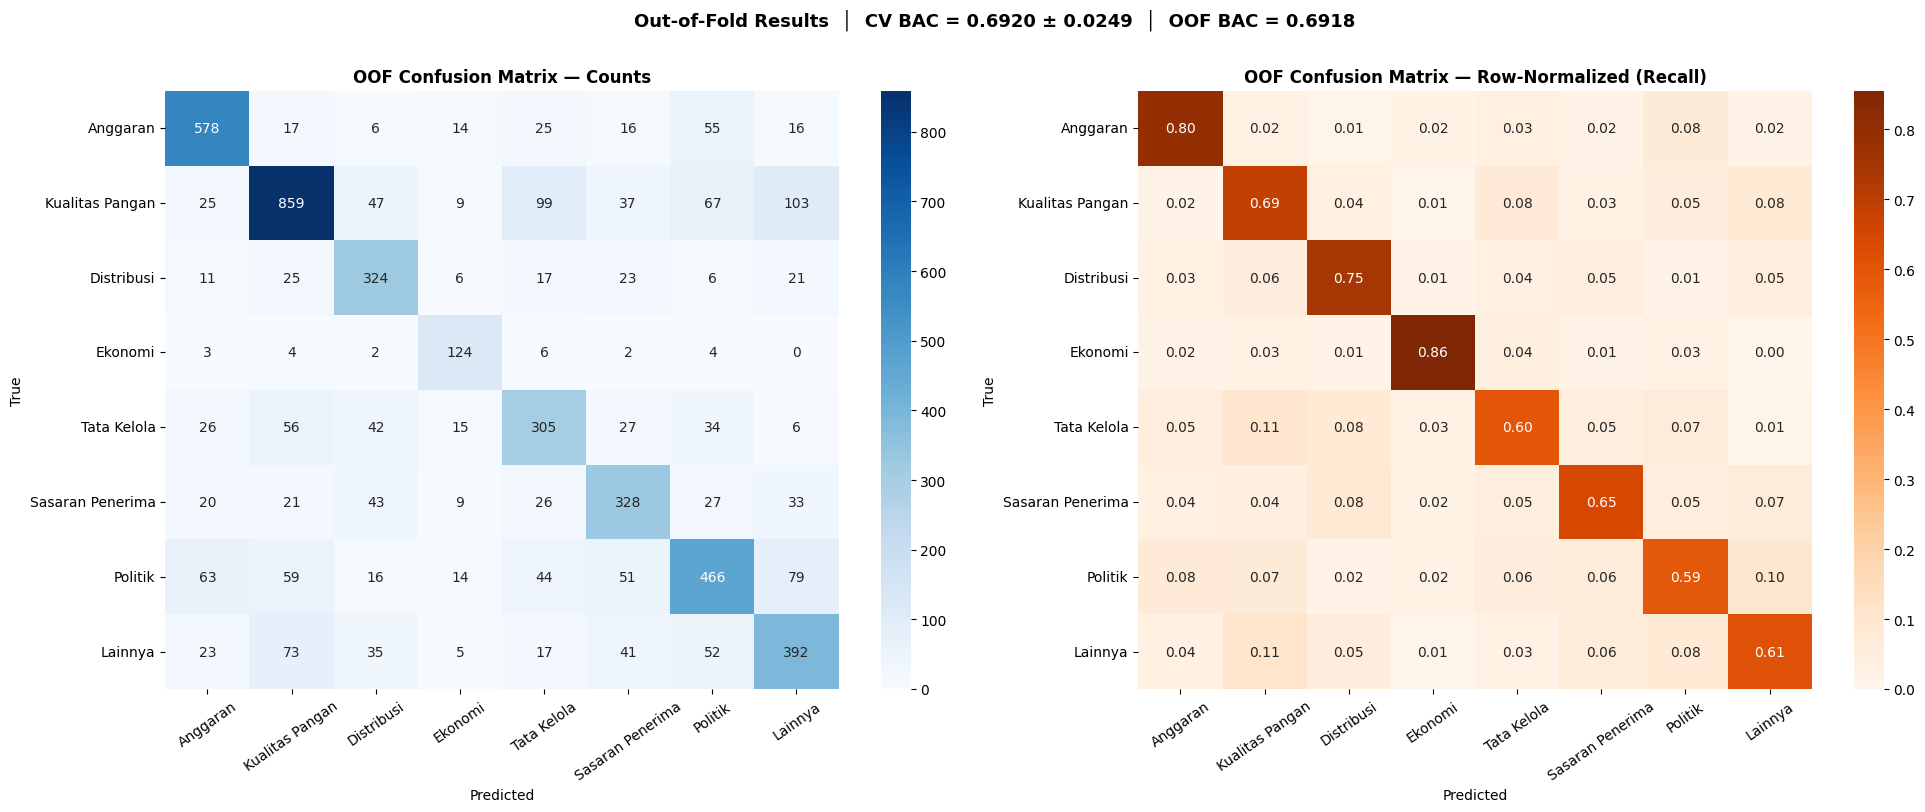

Saved → oof_confusion_matrix.png


In [14]:
# ── Post-training: OOF summary ────────────────────────────────────────────────
fold_scores = [fold_registry[f]['score'] for f in sorted(fold_registry)]
mean_bac    = np.mean(fold_scores)
std_bac     = np.std(fold_scores)
oof_bac     = balanced_accuracy_score(labels_arr, oof_preds_arr)

print("=" * 60)
print(" CROSS-VALIDATION SUMMARY")
print("=" * 60)
summary_df = pd.DataFrame([
    {'Fold': f, 'Val BAC': fold_registry[f]['score']}
    for f in sorted(fold_registry)
])
display(summary_df)
print(f"\nCV  Balanced Accuracy : {mean_bac:.4f} ± {std_bac:.4f}")
print(f"OOF Balanced Accuracy : {oof_bac:.4f}")

# ── OOF confusion matrix ──────────────────────────────────────────────────────
cm_oof      = confusion_matrix(labels_arr, oof_preds_arr)
cm_oof_norm = cm_oof.astype(float) / cm_oof.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm_oof, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_CLASSES, yticklabels=LABEL_CLASSES, ax=axes[0])
axes[0].set_title('OOF Confusion Matrix — Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_oof_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=LABEL_CLASSES, yticklabels=LABEL_CLASSES, ax=axes[1])
axes[1].set_title('OOF Confusion Matrix — Row-Normalized (Recall)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(
    f'Out-of-Fold Results  │  CV BAC = {mean_bac:.4f} ± {std_bac:.4f}  │  OOF BAC = {oof_bac:.4f}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('oof_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → oof_confusion_matrix.png")

---
# **Ensemble Filtering Logic (Top-Folds Selection)**

In [15]:
# ── Sort folds by validation BAC (descending) ─────────────────────────────────
sorted_folds = sorted(
    fold_registry.items(),
    key=lambda kv: kv[1]['score'],
    reverse=True,
)

print("=" * 60)
print(" FOLDS SORTED BY VALIDATION BALANCED ACCURACY")
print("=" * 60)
print(f"  {'Fold':>5}  {'Val BAC':>10}  {'Checkpoint'}")
print("-" * 58)
for fold_id, info in sorted_folds:
    print(f"  {fold_id:>5}  {info['score']:>10.4f}  {info['ckpt_dir']}")

# ── Select only the top fold (best score) ─────────────────────────────────────
max_score   = sorted_folds[0][1]['score']
selected_folds = [sorted_folds[0]]  # Only the top fold

print()
print("=" * 60)
print(f" SELECTED FOLD FOR INFERENCE")
print("=" * 60)
print(f"  {'Fold':>5}  {'Val BAC':>10}")
print("-" * 20)
for fold_id, info in selected_folds:
    print(f"  {fold_id:>5}  {info['score']:>10.4f}")
print()
print(f"Total folds in ensemble : {len(selected_folds)} / {N_FOLDS}")
print(f"Selected fold ID        : {[fid for fid, _ in selected_folds]}")


 FOLDS SORTED BY VALIDATION BALANCED ACCURACY
   Fold     Val BAC  Checkpoint
----------------------------------------------------------
      5      0.7285  model_fold/fold_05
      2      0.7241  model_fold/fold_02
      8      0.7192  model_fold/fold_08
      3      0.6939  model_fold/fold_03
      6      0.6919  model_fold/fold_06
      7      0.6914  model_fold/fold_07
      9      0.6883  model_fold/fold_09
     10      0.6674  model_fold/fold_10
      4      0.6641  model_fold/fold_04
      1      0.6511  model_fold/fold_01

 SELECTED FOLD FOR INFERENCE
   Fold     Val BAC
--------------------
      5      0.7285

Total folds in ensemble : 1 / 10
Selected fold ID        : [5]


---
# **Final Ensemble Inference & Export**

In [16]:
# ── 9-A  Load test data ───────────────────────────────────────────────────────
df_test = load_flexible(PREDICT_PATH)

print(f"Test data shape   : {df_test.shape}")
print(f"Test data columns : {df_test.columns.tolist()}")
display(df_test.head(8))

Test data shape   : (1500, 2)
Test data columns : ['id', 'full_text']


,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo
5,TXT0006,"Mohon diloloskan min,, \n\nkejadian makan berg..."
6,TXT0007,Luar biasa putra bangsa miklos sunario berbica...
7,TXT0008,kegagalan elu. boong aje 19 juta lapangan peke...


In [17]:
# ── 9-B  Apply IDENTICAL cleaning function from Cell 4 ───────────────────────
df_test['text_clean'] = df_test['full_text'].apply(clean_tweet)

print("Test set after cleaning (head 8):")
display(df_test[['id', 'full_text', 'text_clean']].head(8))
print(f"\nEmpty texts after cleaning : {(df_test['text_clean'].str.strip() == '').sum()}")

Test set after cleaning (head 8):


,id,full_text,text_clean
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...,makan bergizi gratis di sekolah kota aku belum...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,wkwkkdidaerah ku pun yang dapat makan bergizi ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...","tahi tau tidak ,gak semua sekolah dapat makan ..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...","gencar cegah stunting, makan bergizi gratis te..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo,140 siswa kupang keracunan program makan bergi...
5,TXT0006,"Mohon diloloskan min,, \n\nkejadian makan berg...","mohon diloloskan min,, kejadian makan bergizi ..."
6,TXT0007,Luar biasa putra bangsa miklos sunario berbica...,luar biasa putra bangsa miklos sunario berbica...
7,TXT0008,kegagalan elu. boong aje 19 juta lapangan peke...,kegagalan elu. bohong saja 19 juta lapangan pe...



Empty texts after cleaning : 0


In [18]:
# ── 9-C  Tokenize test set as HF Dataset ─────────────────────────────────────
test_hf = Dataset.from_dict({'text': df_test['text_clean'].tolist()})

def tokenize_test_batch(examples):
    return tokenizer(
        examples['text'],
        max_length = MAX_LEN,
        truncation = True,
        padding    = False,
    )

test_hf = test_hf.map(
    tokenize_test_batch, batched=True, remove_columns=['text'],
    desc='Tokenizing test set'
)
test_hf.set_format('torch')

print(f"Test HF dataset : {len(test_hf):,} samples")
print(f"Columns         : {test_hf.column_names}")

Tokenizing test set:   0%|          | 0/1500 [00:00<?, ? examples/s]

Test HF dataset : 1,500 samples
Columns         : ['input_ids', 'token_type_ids', 'attention_mask']


In [19]:
# ── 9-D  Soft-Voting Ensemble Inference ───────────────────────────────────────
#
# For each selected fold:
#   1. Reload the best checkpoint saved by Trainer.
#   2. Run forward pass on full test set.
#   3. Apply Softmax → probability matrix  (N_test × NUM_CLASSES).
#   4. Accumulate probabilities into ensemble_probs.
#
# After all selected folds:
#   5. Divide accumulated probs by number of selected folds → mean probs.
#   6. argmax → final label IDs → map to label strings.

N_TEST        = len(test_hf)
ensemble_probs = np.zeros((N_TEST, NUM_CLASSES), dtype=np.float64)

# Minimal TrainingArguments just for Trainer.predict()
_inf_args = TrainingArguments(
    output_dir              = './tmp_inf',
    per_device_eval_batch_size = 64,
    fp16                    = (DEVICE.type == 'cuda'),
    dataloader_num_workers  = 2,
    report_to               = 'none',
)

print("=" * 65)
print(f" SOFT-VOTING ENSEMBLE OVER {len(selected_folds)} SELECTED FOLDS")
print("=" * 65)

for rank, (fold_id, info) in enumerate(selected_folds, start=1):
    ckpt_dir  = info['ckpt_dir']
    fold_score = info['score']

    print(f"\n  [{rank}/{len(selected_folds)}] Loading Fold {fold_id}  "
          f"(BAC = {fold_score:.4f})  from: {ckpt_dir}")

    # ── If the fold folder contains exactly one subfolder, use that subfolder
    PathClass = CHECKPOINT_ROOT.__class__    # PosixPath class (avoid re-import)
    fold_path = PathClass(ckpt_dir)
    try:
        subdirs = [p for p in fold_path.iterdir() if p.is_dir()]
    except Exception:
        subdirs = []

    if len(subdirs) == 1:
        ckpt_to_load = str(subdirs[0])
        print(f"     Using nested checkpoint folder: {ckpt_to_load}")
    else:
        ckpt_to_load = ckpt_dir
        if len(subdirs) > 1:
            print(f"     Multiple subfolders found, using parent ckpt dir: {ckpt_dir}")
        else:
            print(f"     No nested folder found, using ckpt dir: {ckpt_dir}")

    # ── Load the best checkpoint for this fold ─────────────────────────
    fold_model = AutoModelForSequenceClassification.from_pretrained(
        ckpt_to_load,
        num_labels              = NUM_CLASSES,
        ignore_mismatched_sizes = True,
    )

    _inf_trainer = Trainer(
        model         = fold_model,
        args          = _inf_args,
        # tokenizer     = tokenizer,
        data_collator = data_collator,
    )

    # ── Predict: returns raw logits ────────────────────────────────────
    raw_pred = _inf_trainer.predict(test_hf)
    logits   = raw_pred.predictions            # shape: (N_TEST, NUM_CLASSES)

    # ── Softmax → probabilities ────────────────────────────────────────
    probs = F.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
    print(f"     Logits shape : {logits.shape}  |  Probs shape : {probs.shape}")

    # ── Accumulate into ensemble sum ───────────────────────────────────
    ensemble_probs += probs

    # ── Release VRAM ───────────────────────────────────────────────────
    del fold_model, _inf_trainer
    torch.cuda.empty_cache()

    print(f"     Accumulated probs shape: {ensemble_probs.shape}")

# ── Average (Soft Voting) ─────────────────────────────────────────────────────
mean_probs      = ensemble_probs / len(selected_folds)   # shape: (N_TEST, NUM_CLASSES)
final_label_ids = np.argmax(mean_probs, axis=-1)         # shape: (N_TEST,)
final_labels    = [ID2LABEL[lid] for lid in final_label_ids]
final_confidence = mean_probs.max(axis=-1)               # shape: (N_TEST,)

print()
print("=" * 65)
print(f" ENSEMBLE INFERENCE COMPLETE")
print(f" Predicted {len(final_labels):,} samples using {len(selected_folds)} models.")
print("=" * 65)

 SOFT-VOTING ENSEMBLE OVER 1 SELECTED FOLDS

  [1/1] Loading Fold 5  (BAC = 0.7285)  from: model_fold/fold_05
     Using nested checkpoint folder: model_fold/fold_05/checkpoint-423


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

     Logits shape : (1500, 8)  |  Probs shape : (1500, 8)
     Accumulated probs shape: (1500, 8)

 ENSEMBLE INFERENCE COMPLETE
 Predicted 1,500 samples using 1 models.


 SUBMISSION PREVIEW (first 20 rows)


,id,label,confidence
0,TXT0001,Distribusi,0.9706
1,TXT0002,Distribusi,0.5499
2,TXT0003,Kualitas Pangan,0.8875
3,TXT0004,Sasaran Penerima,0.9707
4,TXT0005,Kualitas Pangan,0.9122
5,TXT0006,Kualitas Pangan,0.4517
6,TXT0007,Politik,0.6881
7,TXT0008,Ekonomi,0.5907
8,TXT0009,Kualitas Pangan,0.8873
9,TXT0010,Politik,0.5037




 PREDICTED CLASS DISTRIBUTION
  Anggaran                 228  █████████████████████████
  Kualitas Pangan          322  ███████████████████████████████████
  Distribusi               161  ██████████████████
  Ekonomi                   65  ███████
  Tata Kelola              137  ███████████████
  Sasaran Penerima         178  ███████████████████
  Politik                  206  ██████████████████████
  Lainnya                  203  ██████████████████████


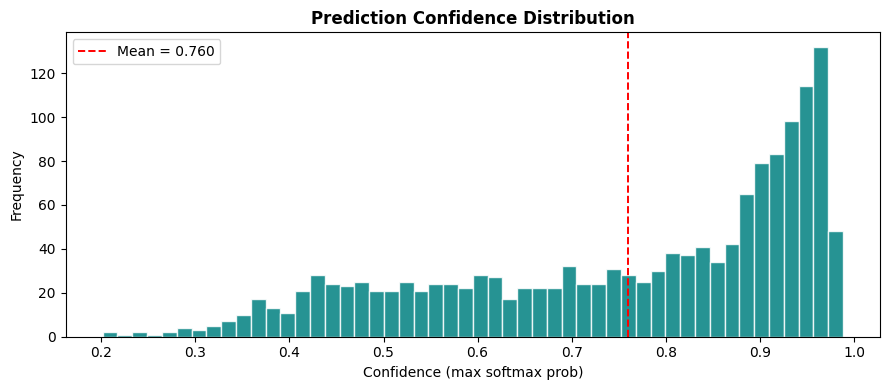

Saved → inference_confidence.png


In [20]:
# ── 9-E  Build submission DataFrame & inspect ─────────────────────────────────
df_submission = df_test[['id']].copy()
df_submission['label']      = final_labels
df_submission['confidence'] = final_confidence.round(4)  # diagnostic; remove if unwanted

print("=" * 55)
print(" SUBMISSION PREVIEW (first 20 rows)")
print("=" * 55)
display(df_submission.head(20))

print("\n")
print("=" * 55)
print(" PREDICTED CLASS DISTRIBUTION")
print("=" * 55)
pred_dist = df_submission['label'].value_counts()
for lbl in LABEL_CLASSES:
    cnt = pred_dist.get(lbl, 0)
    bar = '█' * int(cnt / pred_dist.max() * 35 + 0.5)
    print(f"  {lbl:<22} {cnt:>5}  {bar}")

# Confidence distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(final_confidence, bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(final_confidence.mean(), color='red', linestyle='--', linewidth=1.4,
           label=f'Mean = {final_confidence.mean():.3f}')
ax.set_xlabel('Confidence (max softmax prob)')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Confidence Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('inference_confidence.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved → inference_confidence.png")

In [23]:
# ── 9-F  Export to nama_tim.xlsx (matches panitia template: id | label) ───────
df_final = df_submission[['id', 'label']].copy()

df_final.to_excel(OUTPUT_PATH, index=False)

print(f"✓ Submission exported → {OUTPUT_PATH}")
print(f"  Shape : {df_final.shape}")
print()
display(df_final.head(20))

# ── Final pipeline summary ────────────────────────────────────────────────────
print()
print("═" * 65)
print(" PIPELINE COMPLETE — FINAL SUMMARY")
print("═" * 65)
print(f"  Model                  : {MODEL_NAME}")
print(f"  Folds trained          : {N_FOLDS}")
print(f"  CV  Balanced Accuracy  : {mean_bac:.4f} ± {std_bac:.4f}")
print(f"  OOF Balanced Accuracy  : {oof_bac:.4f}")
print(f"  Best fold score        : {max_score:.4f}")
print(f"  Folds in ensemble      : {len(selected_folds)} (delta ≤ {TOP_FOLD_DELTA})")
print(f"  Selected fold IDs      : {[fid for fid, _ in selected_folds]}")
print(f"  Test samples predicted : {len(df_final):,}")
print(f"  Output file            : {OUTPUT_PATH}")
print("═" * 65)

✓ Submission exported → ./Pisau Laut Jawa.xlsx
  Shape : (1500, 2)



,id,label
0,TXT0001,Distribusi
1,TXT0002,Distribusi
2,TXT0003,Kualitas Pangan
3,TXT0004,Sasaran Penerima
4,TXT0005,Kualitas Pangan
5,TXT0006,Kualitas Pangan
6,TXT0007,Politik
7,TXT0008,Ekonomi
8,TXT0009,Kualitas Pangan
9,TXT0010,Politik



═════════════════════════════════════════════════════════════════
 PIPELINE COMPLETE — FINAL SUMMARY
═════════════════════════════════════════════════════════════════
  Model                  : indolem/indobertweet-base-uncased
  Folds trained          : 10
  CV  Balanced Accuracy  : 0.6920 ± 0.0249
  OOF Balanced Accuracy  : 0.6918
  Best fold score        : 0.7285
  Folds in ensemble      : 1 (delta ≤ 0.02)
  Selected fold IDs      : [5]
  Test samples predicted : 1,500
  Output file            : ./Pisau Laut Jawa.xlsx
═════════════════════════════════════════════════════════════════
